# Phase 1: Pre-Cleaning Exploratory Data Analysis (EDA)
This notebook analyzes the raw dataset distributions before any cleaning or imputation.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for all our plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

# Path to the dataset
CSV_PATH = "../data/US_Accidents.csv"

print("Loading a 500k random sample of the 7.7M row dataset...")

# We read in chunks and sample to get a representative subset quickly
chunks = []
for chunk in pd.read_csv(CSV_PATH, chunksize=500_000, low_memory=False):
    chunks.append(chunk.sample(frac=0.065, random_state=42)) 
    
df_raw = pd.concat(chunks, ignore_index=True)

# Parse the Start_Time column to datetime so we can extract hours later
df_raw['Start_Time'] = pd.to_datetime(df_raw['Start_Time'], format='mixed')

print(f"Successfully loaded raw sample! Size: {len(df_raw):,} rows and {df_raw.shape[1]} columns.")
print("Last row:")
print(df_raw.tail(1))

Loading a 500k random sample of the 7.7M row dataset...
Successfully loaded raw sample! Size: 502,346 rows and 46 columns.
Last row:
               ID   Source  Severity          Start_Time             End_Time  \
502345  A-7620915  Source1         4 2018-02-17 00:36:58  2018-02-17 06:36:58   

        Start_Lat  Start_Lng   End_Lat   End_Lng  Distance(mi)  ...  \
502345    34.2672  -79.70796  34.34581 -79.52974        11.531  ...   

       Roundabout Station   Stop Traffic_Calming Traffic_Signal Turning_Loop  \
502345      False   False  False           False          False        False   

       Sunrise_Sunset Civil_Twilight Nautical_Twilight Astronomical_Twilight  
502345          Night          Night             Night                 Night  

[1 rows x 46 columns]


### Graph 1: The Big Canvas
A massive multi-plot canvas showing the distribution of all key features (numeric histograms and categorical bar charts) in one large grid.

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

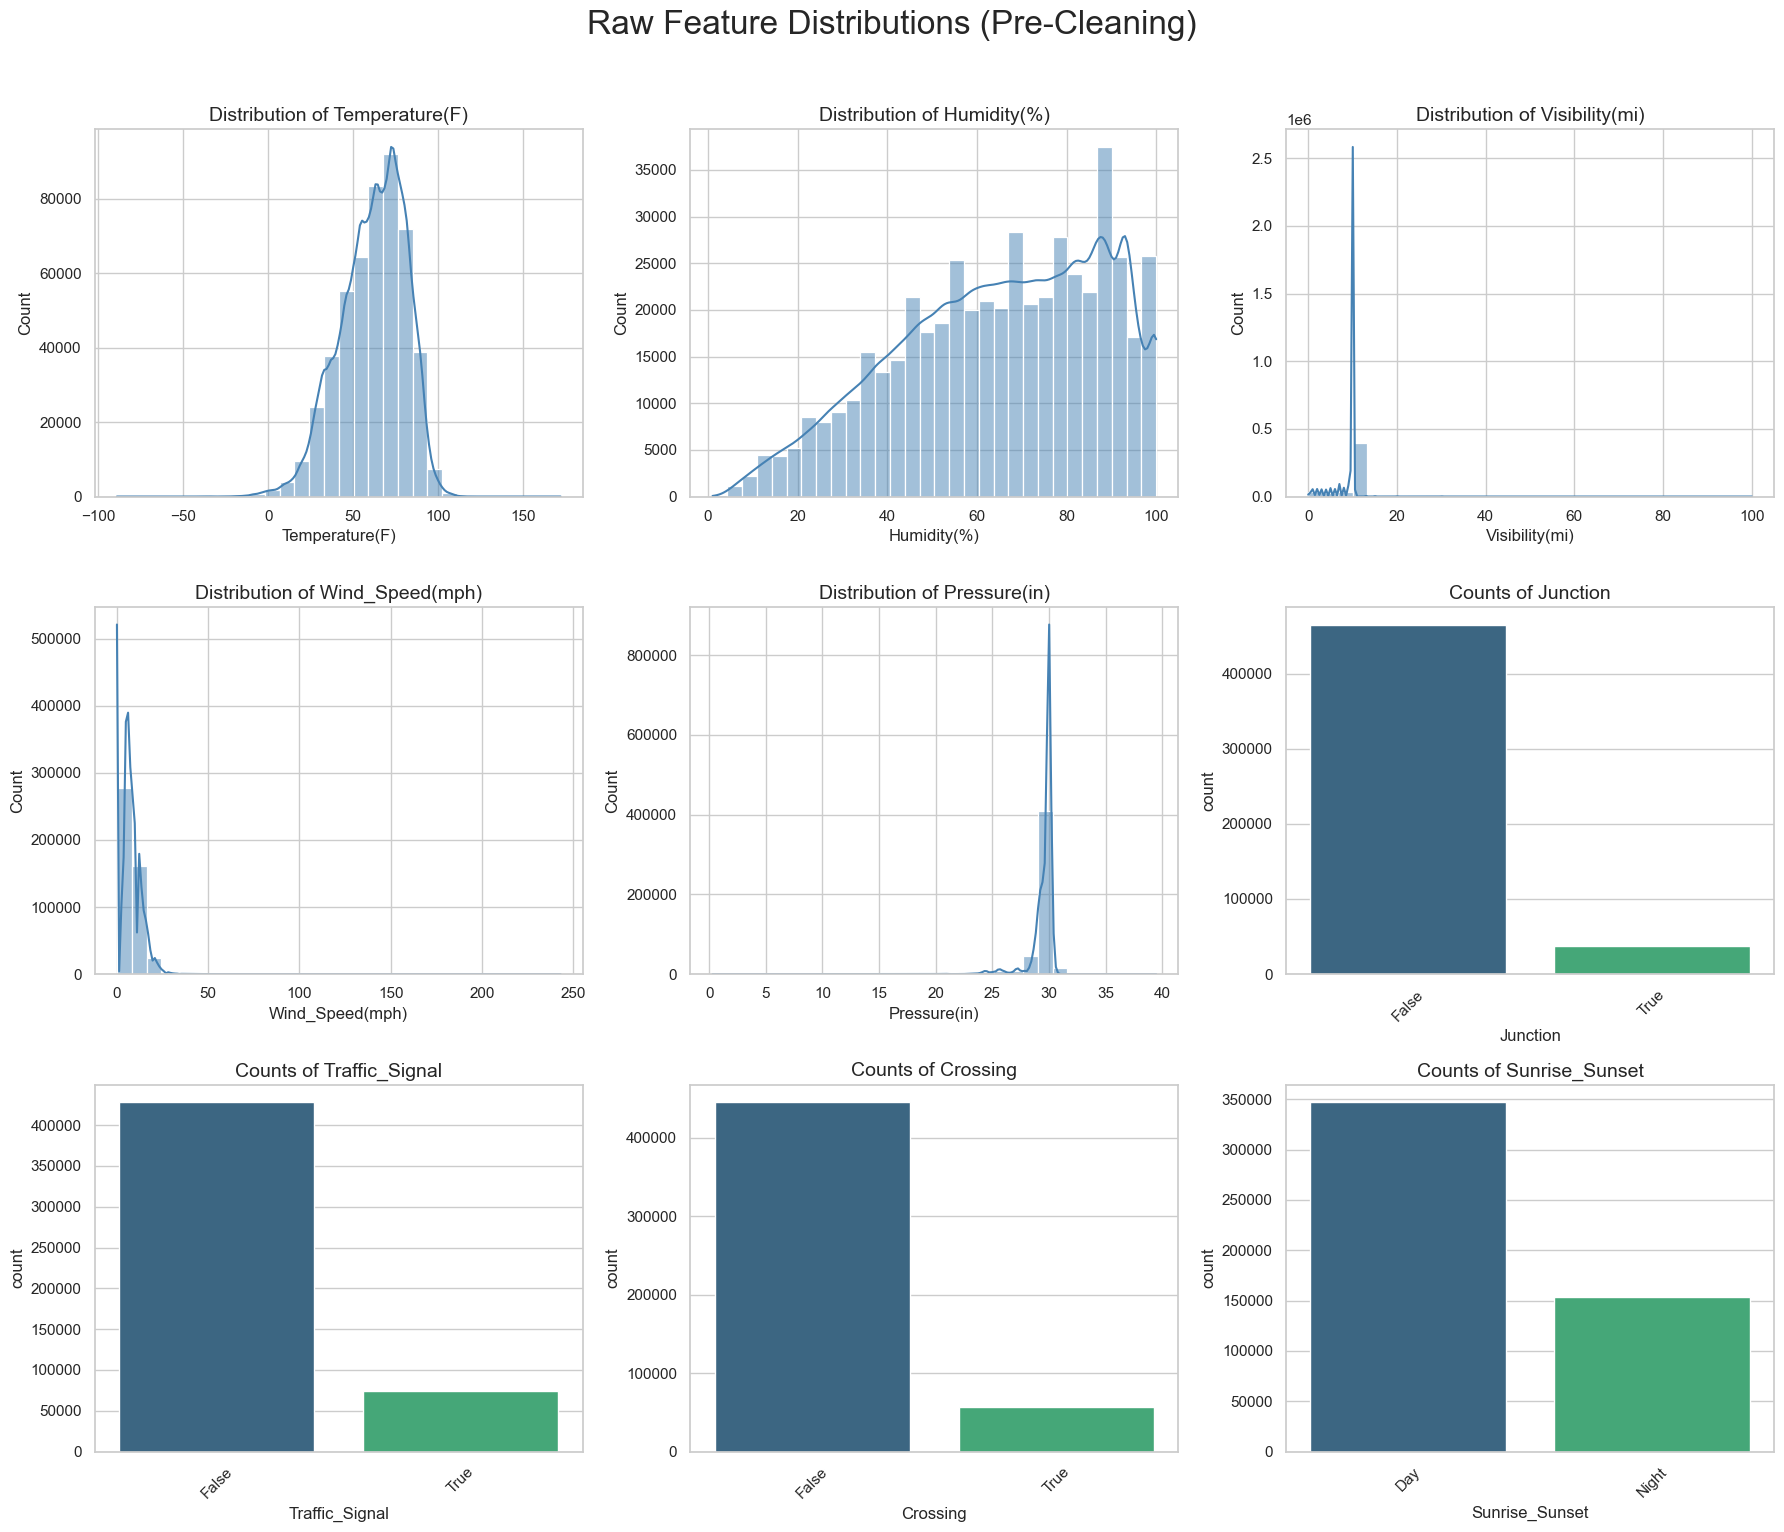

In [2]:
# Select 9 key features to visualize in one big canvas
features_to_plot = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 
                    'Pressure(in)', 'Junction', 'Traffic_Signal', 'Crossing', 'Sunrise_Sunset']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Raw Feature Distributions (Pre-Cleaning)', fontsize=24, y=1.02)
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    # Drop NAs just for plotting purposes
    data = df_raw[feature].dropna()
    
    if data.dtype == 'float64' or data.dtype == 'int64':
        # Numeric features get histograms
        sns.histplot(data, bins=30, ax=ax, color='steelblue', kde=True)
        ax.set_title(f'Distribution of {feature}', fontsize=14)
    else:
        # Categorical/Boolean features get count plots
        sns.countplot(x=data, ax=ax, palette='viridis', order=data.value_counts().index[:10])
        ax.set_title(f'Counts of {feature}', fontsize=14)
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Graph 2: Severity Class Imbalance
Showing the extreme class imbalance in our target variable.

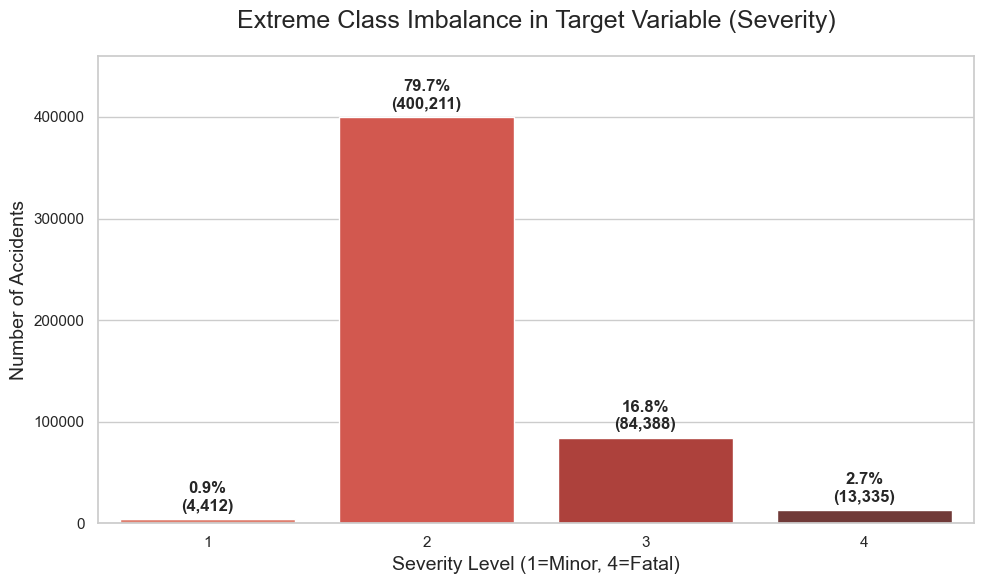

In [3]:
plt.figure(figsize=(10, 6))

# Calculate percentages for the labels
sev_counts = df_raw['Severity'].value_counts().sort_index()
total = len(df_raw)

ax = sns.barplot(x=sev_counts.index, y=sev_counts.values, palette='Reds_d')

# Add percentage labels on top of the bars
for i, count in enumerate(sev_counts.values):
    pct = (count / total) * 100
    ax.text(i, count + (total*0.01), f'{pct:.1f}%\n({count:,})', 
            ha='center', va='bottom', fontweight='bold')

plt.title('Extreme Class Imbalance in Target Variable (Severity)', fontsize=18, pad=20)
plt.xlabel('Severity Level (1=Minor, 4=Fatal)', fontsize=14)
plt.ylabel('Number of Accidents', fontsize=14)

# Force the y-axis to extend a bit higher so labels fit
plt.ylim(0, sev_counts.max() * 1.15)
plt.show()

### Graph 3: Accidents by Hour of Day

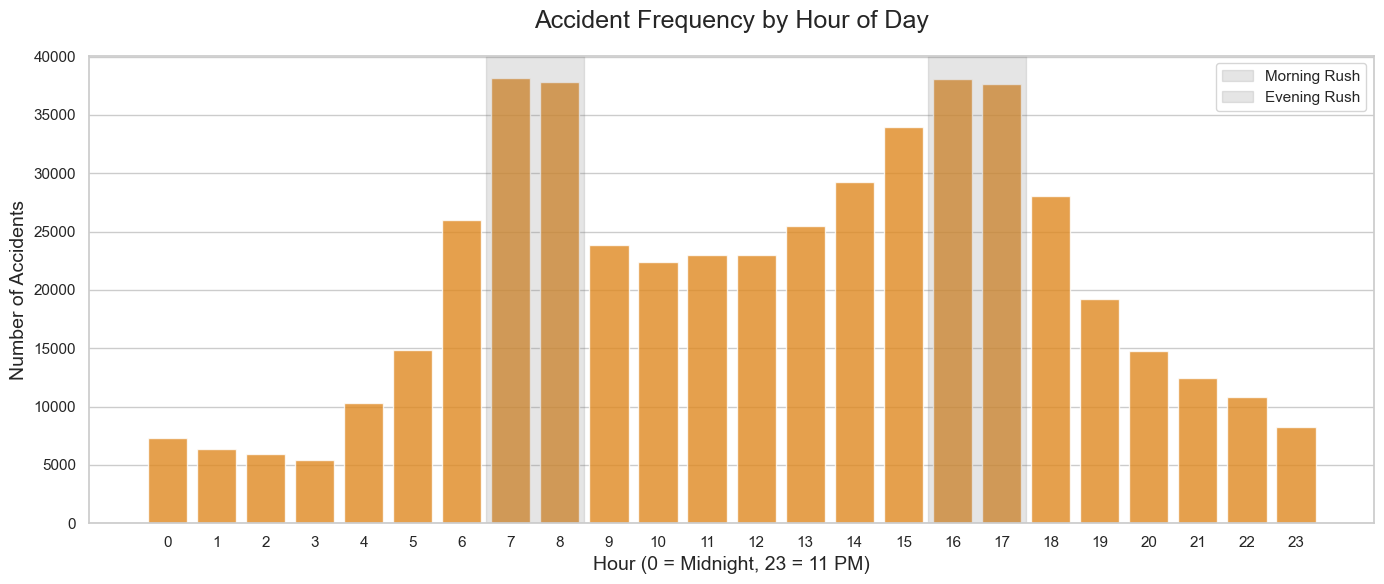

In [4]:
plt.figure(figsize=(14, 6))

# Extract hour from Start_Time
df_raw['Hour'] = df_raw['Start_Time'].dt.hour

ax = sns.countplot(data=df_raw, x='Hour', color='darkorange', alpha=0.8)

plt.title('Accident Frequency by Hour of Day', fontsize=18, pad=20)
plt.xlabel('Hour (0 = Midnight, 23 = 11 PM)', fontsize=14)
plt.ylabel('Number of Accidents', fontsize=14)

# Highlight rush hours
ax.axvspan(6.5, 8.5, color='gray', alpha=0.2, label='Morning Rush')
ax.axvspan(15.5, 17.5, color='gray', alpha=0.2, label='Evening Rush')
plt.legend()

plt.show()

### Graph 4: Severity vs. Weather Condition

<Figure size 1400x800 with 0 Axes>

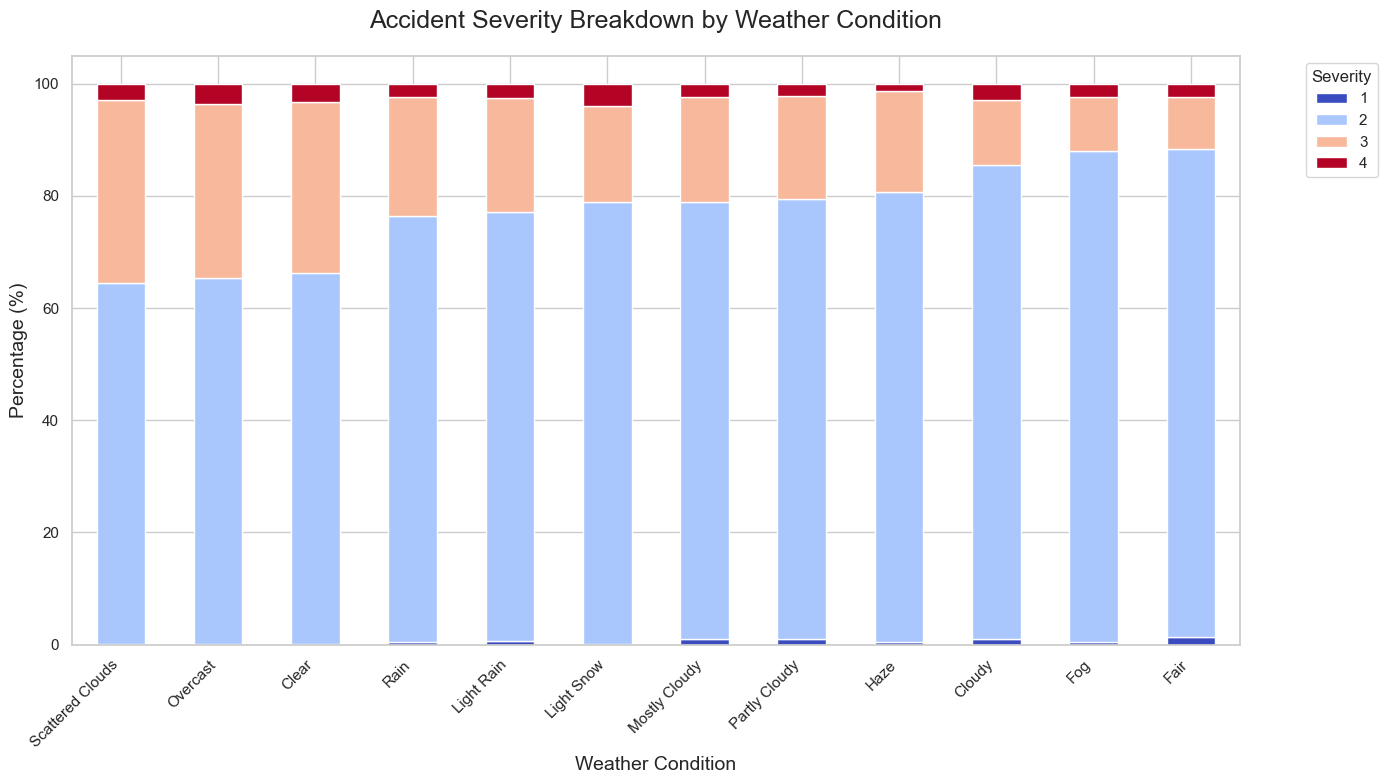

In [5]:
plt.figure(figsize=(14, 8))

# Filter to top 12 weather conditions to keep the chart readable
top_weather = df_raw['Weather_Condition'].value_counts().head(12).index
df_weather = df_raw[df_raw['Weather_Condition'].isin(top_weather)]

# Create a normalized crosstab (percentages instead of raw counts)
weather_sev_crosstab = pd.crosstab(df_weather['Weather_Condition'], df_weather['Severity'], normalize='index') * 100

# Sort by the percentage of Severity 3 + 4 (Severe/Fatal)
weather_sev_crosstab['Severe_Pct'] = weather_sev_crosstab.get(3, 0) + weather_sev_crosstab.get(4, 0)
weather_sev_crosstab = weather_sev_crosstab.sort_values('Severe_Pct', ascending=False).drop(columns=['Severe_Pct'])

# Stacked bar chart
weather_sev_crosstab.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(14, 8))

plt.title('Accident Severity Breakdown by Weather Condition', fontsize=18, pad=20)
plt.xlabel('Weather Condition', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=14)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

### Graph 5: Geographic spread (Top 10 States)

/var/folders/bn/syn6z63d1llgjp9x8hgg3chw0000gn/T/ipykernel_11648/1161840037.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


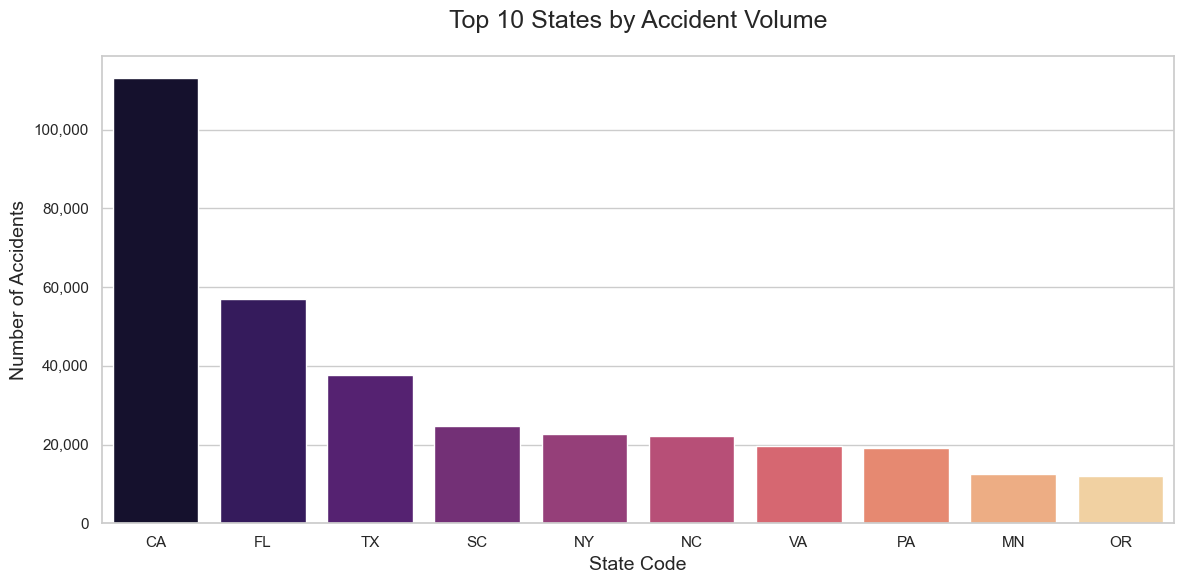

In [6]:
plt.figure(figsize=(12, 6))

top_10_states = df_raw['State'].value_counts().head(10)

sns.barplot(x=top_10_states.index, y=top_10_states.values, palette='magma')

plt.title('Top 10 States by Accident Volume', fontsize=18, pad=20)
plt.xlabel('State Code', fontsize=14)
plt.ylabel('Number of Accidents', fontsize=14)

# Add comma formatting to y-axis
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.show()